# 03 — Évaluation finale et Analyse des Erreurs

**Objectifs de ce notebook :**
- Charger le meilleur checkpoint
- Calculer toutes les métriques sur le test set
- Tracer la matrice de confusion et la courbe ROC
- Analyser les faux négatifs (FN) et faux positifs (FP)
- Visualiser Grad-CAM (optionnel)

> **Jours J8 et J9 du plan de 10 jours**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)

from dataset import get_dataloaders, CLASS_NAMES
from model import get_model

CHECKPOINT = '../outputs/checkpoints/best_model.pt'
DATA_DIR   = '../data/chest_xray'
FIGURES    = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Appareil : {device.upper()}')

Appareil : CPU


## 1. Chargement du checkpoint

In [2]:
ckpt = torch.load(CHECKPOINT, map_location=device)
arch = ckpt.get('architecture', 'baseline')

model = get_model(arch).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f'Architecture     : {arch}')
print(f'Époque sauvegard.: {ckpt.get("epoch", "?")} ')
print(f'Val loss (train) : {ckpt.get("val_loss", "?"):.4f}')
print(f'Val acc  (train) : {ckpt.get("val_acc",  "?"):.4f}')

Architecture     : baseline
Époque sauvegard.: 7 
Val loss (train) : 0.5931
Val acc  (train) : 0.8125


## 2. Inférence sur le test set

In [3]:
_, _, test_loader = get_dataloaders(DATA_DIR, batch_size=32, num_workers=0)

all_labels, all_probs = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device)).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

y_true = np.concatenate(all_labels)
y_prob = np.concatenate(all_probs)
y_pred = (y_prob >= 0.5).astype(int)

print(f'Test set : {len(y_true)} images')
print(f'Positifs réels (PNEUMONIA) : {y_true.sum()}')
print(f'Négatifs réels (NORMAL)    : {(1-y_true).sum()}')

  [train]  5216 images  |  classes : {'NORMAL': 0, 'PNEUMONIA': 1}
  [val  ]    16 images  |  classes : {'NORMAL': 0, 'PNEUMONIA': 1}
  [test ]   624 images  |  classes : {'NORMAL': 0, 'PNEUMONIA': 1}


c:\PROJET FINAL DL\medical-cnn-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test set : 624 images
Positifs réels (PNEUMONIA) : 390
Négatifs réels (NORMAL)    : 234


## 3. Métriques complètes

In [4]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
auc_score = roc_auc_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print('=' * 45)
print('  RÉSULTATS FINAUX — TEST SET')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}  <- PRIORITAIRE')
print(f'  F1-score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc_score:.4f}')
print(f'\n  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
fnr = fn / (fn + tp)
print(f'  FNR (taux faux négatifs) : {fnr:.4f} ({fn} pneumonies manquées)')

print('\n' + classification_report(y_true, y_pred, target_names=CLASS_NAMES))

  RÉSULTATS FINAUX — TEST SET
  Accuracy  : 0.8349  (83.5%)
  Precision : 0.9184
  Recall    : 0.8077  <- PRIORITAIRE
  F1-score  : 0.8595
  AUC-ROC   : 0.9107

  TN=206  FP=28  FN=75  TP=315
  FNR (taux faux négatifs) : 0.1923 (75 pneumonies manquées)

              precision    recall  f1-score   support

      NORMAL       0.73      0.88      0.80       234
   PNEUMONIA       0.92      0.81      0.86       390

    accuracy                           0.83       624
   macro avg       0.83      0.84      0.83       624
weighted avg       0.85      0.83      0.84       624



## 4. Matrice de confusion

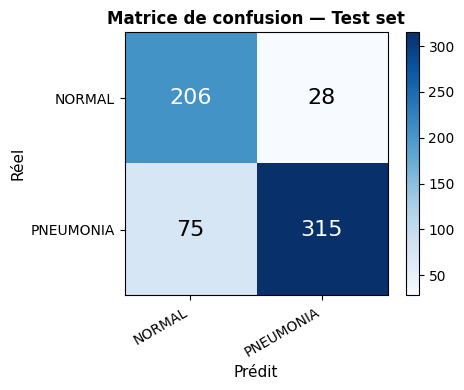

Saved -> outputs/figures/confusion_matrix.png


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(2)); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_yticks(range(2)); ax.set_yticklabels(CLASS_NAMES)

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=16)

ax.set_ylabel('Réel', fontsize=11)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_title('Matrice de confusion — Test set', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved -> outputs/figures/confusion_matrix.png')

## 5. Courbe ROC

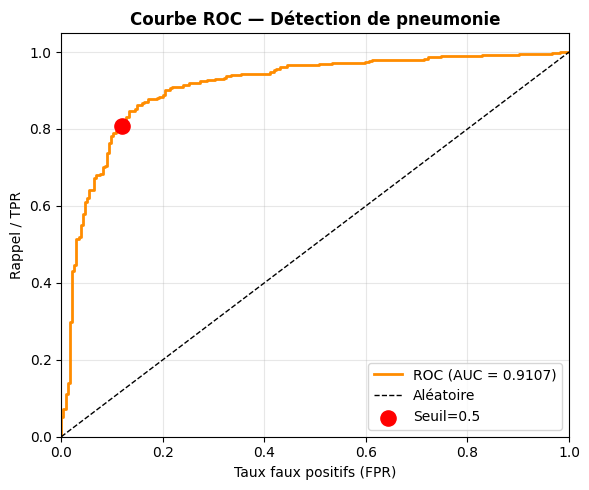

Saved -> outputs/figures/roc_curve.png


In [6]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')

# Marquer le seuil 0.5
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], s=120, color='red', zorder=5, label=f'Seuil=0.5')

ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('Taux faux positifs (FPR)')
ax.set_ylabel('Rappel / TPR')
ax.set_title('Courbe ROC — Détection de pneumonie', fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'roc_curve.png', dpi=150)
plt.show()
print('Saved -> outputs/figures/roc_curve.png')

## 6. Visualisation des erreurs (FN et FP)

c:\PROJET FINAL DL\medical-cnn-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Erreurs collectées : 11
  FN (pneumonie ratée) : 0
  FP (fausse alarme)   : 11


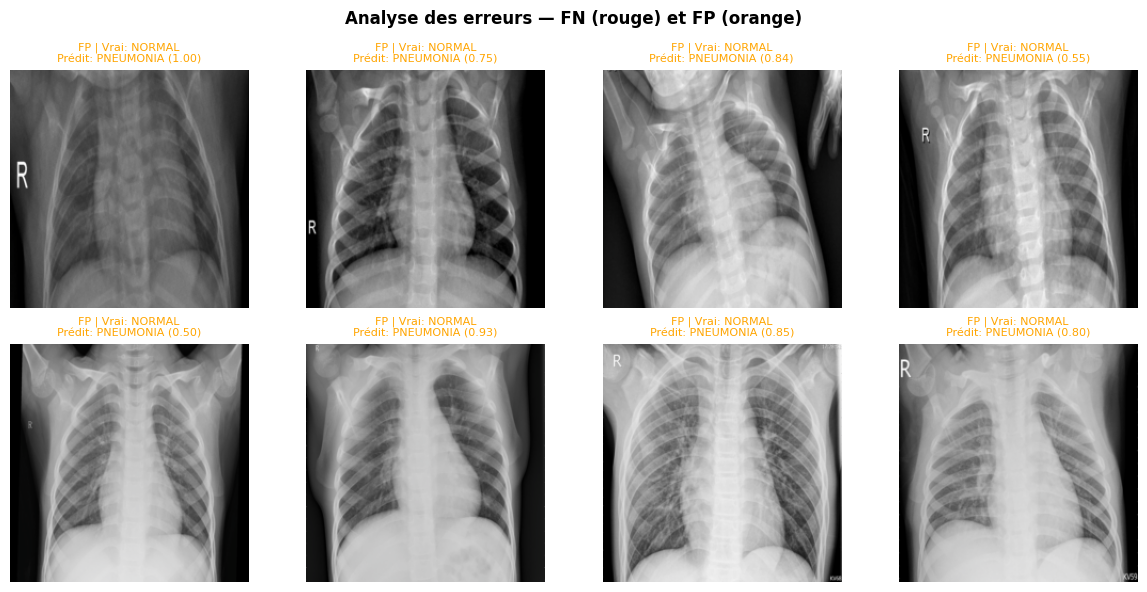

Saved -> outputs/figures/error_analysis.png


In [7]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

errors = []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device)).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        for img, lbl, pred, prob in zip(imgs.numpy(), labels.numpy(), preds, probs):
            if lbl != pred:
                img_disp = np.clip(img.transpose(1, 2, 0) * STD + MEAN, 0, 1)
                errors.append({
                    'img' : img_disp,
                    'true': CLASS_NAMES[lbl],
                    'pred': CLASS_NAMES[pred],
                    'prob': float(prob),
                    'type': 'FN' if lbl == 1 else 'FP'
                })
        if len(errors) >= 8:
            break

print(f'Erreurs collectées : {len(errors)}')
fn_count = sum(1 for e in errors if e['type'] == 'FN')
fp_count = sum(1 for e in errors if e['type'] == 'FP')
print(f'  FN (pneumonie ratée) : {fn_count}')
print(f'  FP (fausse alarme)   : {fp_count}')

if errors:
    n = min(8, len(errors))
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, err in zip(axes.flatten(), errors[:n]):
        ax.imshow(err['img'])
        color = 'red' if err['type'] == 'FN' else 'orange'
        ax.set_title(f"{err['type']} | Vrai: {err['true']}\nPrédit: {err['pred']} ({err['prob']:.2f})",
                     color=color, fontsize=8)
        ax.axis('off')
    plt.suptitle('Analyse des erreurs — FN (rouge) et FP (orange)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'error_analysis.png', dpi=150)
    plt.show()
    print('Saved -> outputs/figures/error_analysis.png')

## 7. Grad-CAM (extension optionnelle — J9)

In [8]:
# Décommentez après avoir installé opencv-python
# from gradcam import GradCAM, get_target_layer, load_image, overlay_heatmap
# from pathlib import Path
# 
# # Choisir une image PNEUMONIA du test set
# test_pneumonia = list(Path('../data/chest_xray/test/PNEUMONIA').glob('*.jpeg'))
# img_path = str(test_pneumonia[0])
# 
# img_tensor, img_np = load_image(img_path)
# target_layer = get_target_layer(model)
# gradcam = GradCAM(model, target_layer, device=device)
# cam = gradcam.generate(img_tensor)
# superimposed = overlay_heatmap(cam, img_np)
# 
# fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# axes[0].imshow(img_np);       axes[0].set_title('Originale');   axes[0].axis('off')
# axes[1].imshow(cam, cmap='jet'); axes[1].set_title('CAM');       axes[1].axis('off')
# axes[2].imshow(superimposed); axes[2].set_title('Superposée'); axes[2].axis('off')
# plt.suptitle('Grad-CAM', fontsize=12)
# plt.tight_layout()
# plt.savefig(FIGURES / 'gradcam_example.png', dpi=150)
# plt.show()
print('Grad-CAM disponible dans src/gradcam.py')
print('Décommentez les cellules ci-dessus pour activer.')

Grad-CAM disponible dans src/gradcam.py
Décommentez les cellules ci-dessus pour activer.


## 8. Résumé final

In [9]:
import json
summary = {
    'architecture': arch,
    'test_accuracy' : round(acc, 4),
    'test_precision': round(prec, 4),
    'test_recall'   : round(rec, 4),
    'test_f1'       : round(f1, 4),
    'test_auc'      : round(float(auc_score), 4),
    'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)},
    'false_negative_rate': round(fnr, 4),
}

out_path = Path('../reports/evaluation_results.json')
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('=== RÉSUMÉ FINAL ===')
print(json.dumps(summary, indent=2))
print(f'\nResultats sauvegardes -> {out_path}')

=== RÉSUMÉ FINAL ===
{
  "architecture": "baseline",
  "test_accuracy": 0.8349,
  "test_precision": 0.9184,
  "test_recall": 0.8077,
  "test_f1": 0.8595,
  "test_auc": 0.9107,
  "confusion_matrix": {
    "TN": 206,
    "FP": 28,
    "FN": 75,
    "TP": 315
  },
  "false_negative_rate": 0.1923
}

Resultats sauvegardes -> ..\reports\evaluation_results.json
